In [20]:
import numpy  as np
import matplotlib.pyplot as plt

In [29]:
# Generate small dataset for logistic regression
np.random.seed(42)

# Class 0
X0 = np.random.randn(50, 2) + np.array([-2, -2])
y0 = np.zeros(50)

# Class 1
X1 = np.random.randn(50, 2) + np.array([2, 2])
y1 = np.ones(50)

# Combine and shuffle
X = np.vstack((X0, X1))
y_true = np.hstack((y0, y1))

idx = np.random.permutation(len(X))
X, y_true = X[idx], y_true[idx]

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y_true.shape}")
print(X)
print(y_true)


Dataset shape: (100, 2)
Labels shape: (100,)
[[ 2.47323762  1.92717109]
 [-2.83921752 -2.30921238]
 [ 0.08122878  1.97348612]
 [-2.47917424 -2.18565898]
 [ 1.02531833  2.7870846 ]
 [-1.17745509 -3.22084365]
 [ 2.25755039  1.92555408]
 [ 1.31997528  2.2322537 ]
 [-0.53435123 -2.2257763 ]
 [-2.90802408 -3.4123037 ]
 [-2.23415337 -2.23413696]
 [ 2.2766908   2.82718325]
 [-2.70205309 -2.32766215]
 [ 1.11614256  2.15372511]
 [ 1.75461188  1.24626384]
 [ 2.96337613  2.41278093]
 [-2.676922   -1.38832371]
 [ 2.81351722  0.76913568]
 [ 1.11048557  1.18418972]
 [ 1.83871429  2.40405086]
 [-2.21967189 -1.64288743]
 [ 1.08057577  3.54993441]
 [ 2.05820872  0.8570297 ]
 [ 1.00946367  1.43370227]
 [ 2.82206016  3.89679298]
 [-1.50328585 -2.1382643 ]
 [-1.90292245 -1.03135501]
 [-1.9324718  -3.42474819]
 [ 1.55348505  2.85639879]
 [-3.47852199 -2.71984421]
 [ 0.93769629  2.47359243]
 [-1.26153342 -1.82863172]
 [-2.07201012 -0.9964671 ]
 [ 2.62566735  1.14284244]
 [-0.96900048 -1.06871988]
 [-4.61974

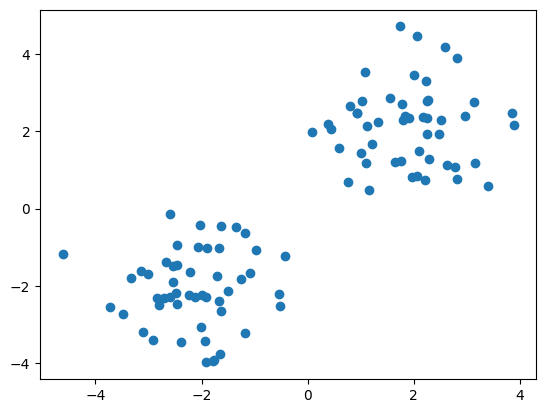

In [22]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [32]:
def model(X,w,b):
    return X@w + b

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def cross_entropy(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


In [44]:
#training
def train_model(X,y,epochs,learning_rate=0.01):
    loss_history = []
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    for epoch in range(epochs):
        z = model(X,w,b)
        y_pred = sigmoid(z)
        loss = cross_entropy(y, y_pred)
        loss_history.append(loss)
        w -= learning_rate*(X.T@(y_pred - y))/n
        b -= learning_rate*np.mean(y_pred - y)

    return w, b, loss_history



In [48]:
#predict
w, b, loss_history = train_model(X, y_true,epochs=100)

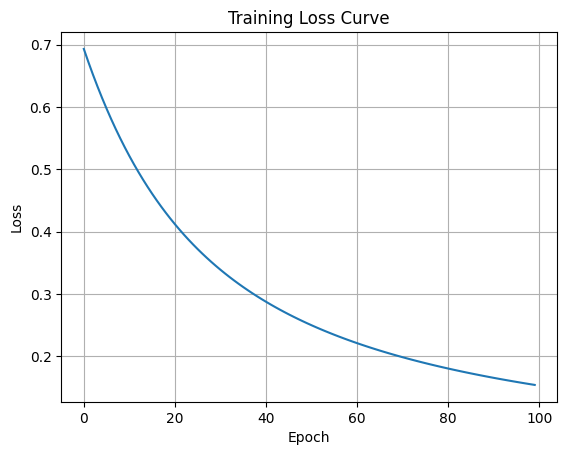

In [49]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

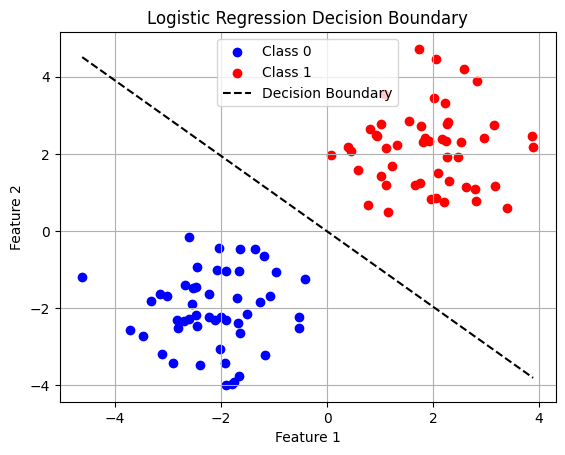

In [51]:
# scatter original data
plt.scatter(X[y_true==0, 0], X[y_true==0, 1], color="blue", label="Class 0")
plt.scatter(X[y_true==1, 0], X[y_true==1, 1], color="red", label="Class 1")

# decision boundary
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
# compute x2 using w1*x1 + w2*x2 + b = 0
# => x2 = -(w1*x1 + b) / w2
x2_vals = -(w[0] * x1_vals + b) / w[1] 
plt.plot(x1_vals, x2_vals, 'k--', label="Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()